# 06 - Experimentacion alrededor del modelo final

Aca se comparan solo variantes del sistema final conceptual: tres bloques log-mel (`headsep`, `globalmel`, `f1024`).


In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'sample_submission.csv').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('No pude encontrar la raiz del repo')
    ROOT = ROOT.parent

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

pd.set_option('display.max_colwidth', 120)

RESULTS = ROOT / '06_experimentacion_final' / 'results'
FIGURES = RESULTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

final_experiments = pd.DataFrame([
    {'candidate': '3-way original', 'formula': '1/3 H + 1/3 G42 + 1/3 F42', 'private_lb': 0.66649, 'status': 'referencia previa', 'csv': 'investigation/results/submissions/simple_headsep_globalmel_f1024_equal.csv'},
    {'candidate': '3-way e100 equal', 'formula': '1/3 H100 + 1/3 G100 + 1/3 F100', 'private_lb': 0.67055, 'status': 'keep', 'csv': 'investigation/results/submissions/parallel100_20260702/e100_headsep_globalmel_f1024_equal.csv'},
    {'candidate': '3-way e100 weighted', 'formula': '0.25 H100 + 0.375 G100 + 0.375 F100', 'private_lb': 0.67126, 'status': 'final oficial', 'csv': 'investigation/results/submissions/parallel100_20260702/e100_headsep25_globalmel375_f1024_375.csv'},
    {'candidate': 'globalmel bagged', 'formula': '0.25 H100 + 0.1875 G42 + 0.1875 G123 + 0.375 F100', 'private_lb': 0.67528, 'status': 'mejor experimento parcial', 'csv': 'investigation/results/submissions/parallel100_20260702/e100_headsep25_globalmel_bag375_f1024_375.csv'},
    {'candidate': 'globalmel + f1024 bagged', 'formula': '0.25 H100 + 0.1875 G42 + 0.1875 G123 + 0.1875 F42 + 0.1875 F123', 'private_lb': 0.67674, 'status': 'mejor score experimental', 'csv': 'investigation/results/submissions/parallel100_20260702/e100_headsep25_globalmelbag375_f1024bag375.csv'},
])
final_experiments['exists'] = final_experiments['csv'].map(lambda p: (ROOT / p).exists())
final_experiments['sha256'] = final_experiments['csv'].map(lambda p: sha256(ROOT / p) if (ROOT / p).exists() else None)
final_experiments.to_csv(RESULTS / 'experimentos_modelo_final.csv', index=False)
display(final_experiments)


,candidate,formula,private_lb,status,csv,exists,sha256
0,3-way original,1/3 H + 1/3 G42 + 1/3 F42,0.66649,referencia previa,investigation/results/submissions/simple_headsep_globalmel_f1024_equal.csv,True,81ce2b49e836ca89b27e07b2f281eebce3efc103d223c29aa6a3731b7659be9b
1,3-way e100 equal,1/3 H100 + 1/3 G100 + 1/3 F100,0.67055,keep,investigation/results/submissions/parallel100_20260702/e100_headsep_globalmel_f1024_equal.csv,True,b68265422943a1484396dd4193746557b64203f5dd0baf3d2b085f5759422156
2,3-way e100 weighted,0.25 H100 + 0.375 G100 + 0.375 F100,0.67126,final oficial,investigation/results/submissions/parallel100_20260702/e100_headsep25_globalmel375_f1024_375.csv,True,4247ab9ff6398fbb1b6af223629d004265e27bb6cbccabf53ec4969a96c61cab
3,globalmel bagged,0.25 H100 + 0.1875 G42 + 0.1875 G123 + 0.375 F100,0.67528,mejor experimento parcial,investigation/results/submissions/parallel100_20260702/e100_headsep25_globalmel_bag375_f1024_375.csv,True,5458c70ebcef2f45836ec63979a34d3e9d3f9bacb875d2c5a2c45755cbf88964
4,globalmel + f1024 bagged,0.25 H100 + 0.1875 G42 + 0.1875 G123 + 0.1875 F42 + 0.1875 F123,0.67674,mejor score experimental,investigation/results/submissions/parallel100_20260702/e100_headsep25_globalmelbag375_f1024bag375.csv,True,7f645f4484980984bc3e7e7ea38940fa781bc1b8546579ad10f6e0c396999019


## Por que se elige `0.67126`

El `0.67674` tiene mejor score, pero usa bagging interno en dos ramas temporales. Es defendible como experimento, pero la entrega oficial prioriza un sistema con tres componentes fisicos directos, pesos simples y explicacion corta.


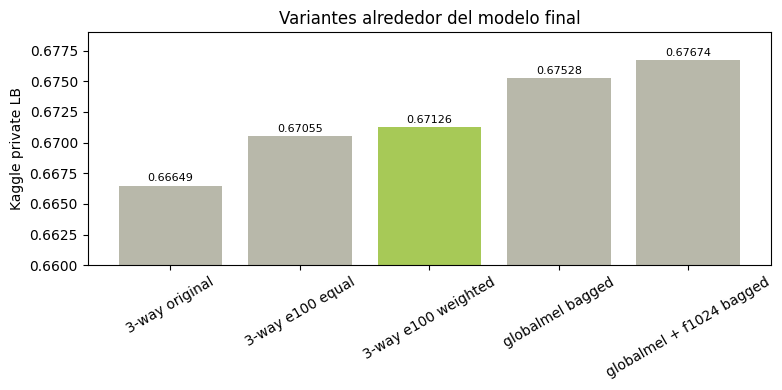

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#a7c957' if status == 'final oficial' else '#b8b8aa' for status in final_experiments['status']]
ax.bar(final_experiments['candidate'], final_experiments['private_lb'], color=colors)
ax.set_ylabel('Kaggle private LB')
ax.set_title('Variantes alrededor del modelo final')
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0.66, 0.679)
for idx, value in enumerate(final_experiments['private_lb']):
    ax.text(idx, value + 0.00035, f'{value:.5f}', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'final_experiments_private_lb.png', dpi=160)
plt.show()


In [3]:
selected = final_experiments[final_experiments['status'].eq('final oficial')].iloc[0]
best = final_experiments.loc[final_experiments['private_lb'].idxmax()]
comparison = {
    'selected_candidate': selected['candidate'],
    'selected_private_lb': float(selected['private_lb']),
    'best_experimental_candidate': best['candidate'],
    'best_experimental_private_lb': float(best['private_lb']),
    'score_gap': float(best['private_lb'] - selected['private_lb']),
    'selection_reason': '3 componentes fisicos directos; bagging queda como experimento',
}
(RESULTS / 'final_selection_reason.json').write_text(json.dumps(comparison, indent=2), encoding='utf-8')
comparison


{'selected_candidate': '3-way e100 weighted',
 'selected_private_lb': 0.67126,
 'best_experimental_candidate': 'globalmel + f1024 bagged',
 'best_experimental_private_lb': 0.67674,
 'score_gap': 0.00548000000000004,
 'selection_reason': '3 componentes fisicos directos; bagging queda como experimento'}

## Conclusion

El final oficial no es el maximo score absoluto, sino el mejor equilibrio entre score y defensa conceptual: tres ramas, 100 epocas y pesos redondos.
